<a href="https://colab.research.google.com/github/Nikhilvijai/internship/blob/main/MultilingualNews_v2_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 — Install (run once, then restart runtime)
!pip install -q transformers==4.44.2 sentencepiece langdetect accelerate torch
print("✅ Done — restart runtime if this is your first run")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 39.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 68.3 MB/s eta 0:00:00
✅ Done — restart runtime if this is your first run


In [ ]:
# Cell 2 — Imports & device setup
import torch
from langdetect import detect, DetectorFactory
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    pipeline
)

# Make language detection deterministic
DetectorFactory.seed = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Imports OK | Device: {'GPU 🚀' if DEVICE == 'cuda' else 'CPU (slower)'}")

✅ Imports OK | Device: GPU 🚀


In [ ]:
# Cell 3 — NLLB language code mapping
# NLLB uses BCP-47 style codes like 'mal_Mlym' instead of 'ml'
# Full list: https://github.com/facebookresearch/flores/blob/main/flores200/README.md

LANGDETECT_TO_NLLB = {
    "af": "afr_Latn",  "ar": "arb_Arab",  "az": "azj_Latn",
    "be": "bel_Cyrl",  "bg": "bul_Cyrl",  "bn": "ben_Beng",
    "ca": "cat_Latn",  "cs": "ces_Latn",  "cy": "cym_Latn",
    "da": "dan_Latn",  "de": "deu_Latn",  "el": "ell_Grek",
    "en": "eng_Latn",  "es": "spa_Latn",  "et": "est_Latn",
    "fa": "pes_Arab",  "fi": "fin_Latn",  "fr": "fra_Latn",
    "ga": "gle_Latn",  "gl": "glg_Latn",  "gu": "guj_Gujr",
    "he": "heb_Hebr",  "hi": "hin_Deva",  "hr": "hrv_Latn",
    "hu": "hun_Latn",  "hy": "hye_Armn",  "id": "ind_Latn",
    "it": "ita_Latn",  "ja": "jpn_Jpan",  "ka": "kat_Geor",
    "kn": "kan_Knda",  "ko": "kor_Hang",  "lt": "lit_Latn",
    "lv": "lvs_Latn",  "mk": "mkd_Cyrl",  "ml": "mal_Mlym",  # Malayalam
    "mr": "mar_Deva",  "ms": "zsm_Latn",  "mt": "mlt_Latn",
    "nl": "nld_Latn",  "no": "nob_Latn",  "pa": "pan_Guru",
    "pl": "pol_Latn",  "pt": "por_Latn",  "ro": "ron_Latn",
    "ru": "rus_Cyrl",  "sk": "slk_Latn",  "sl": "slv_Latn",
    "sq": "als_Latn",  "sr": "srp_Cyrl",  "sv": "swe_Latn",
    "sw": "swh_Latn",  "ta": "tam_Taml",  "te": "tel_Telu",
    "th": "tha_Thai",  "tl": "tgl_Latn",  "tr": "tur_Latn",
    "uk": "ukr_Cyrl",  "ur": "urd_Arab",  "vi": "vie_Latn",
    "zh-cn": "zho_Hans", "zh-tw": "zho_Hant", "zh": "zho_Hans",
}

def detect_language(text):
    try:
        lang = detect(text)
        nllb_code = LANGDETECT_TO_NLLB.get(lang, None)
        print(f"[Detected]: langdetect='{lang}' → NLLB='{nllb_code}'")
        return lang, nllb_code
    except Exception as e:
        print(f"[Detection error]: {e} → defaulting to English")
        return "en", "eng_Latn"

print("✅ Language mapping ready (200 languages)")

✅ Language mapping ready (200 languages)


In [ ]:
# Cell 4 — Load NLLB-200 Translation Model (~1.2GB, loads once)
# facebook/nllb-200-distilled-600M — best accuracy/size tradeoff
# Supports 200 languages vs Helsinki's ~60

NLLB_MODEL = "facebook/nllb-200-distilled-600M"
print(f"[Loading translation model: {NLLB_MODEL}]")
print("(~1.2GB download, takes 1-2 mins on first run)")

nllb_tokenizer = AutoTokenizer.from_pretrained(NLLB_MODEL)
nllb_model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL)

if DEVICE == "cuda":
    nllb_model = nllb_model.to("cuda")

print("✅ NLLB-200 translation model loaded")

def translate_to_english(text, src_nllb_code):
    if src_nllb_code == "eng_Latn" or src_nllb_code is None and "en" in text[:20]:
        print("[Translation]: Already English, skipping.")
        return text

    if src_nllb_code is None:
        print("[Warning]: Unknown language code, attempting translation anyway.")
        src_nllb_code = "eng_Latn"

    # Tokenize with forced source language
    nllb_tokenizer.src_lang = src_nllb_code
    target_lang_id = nllb_tokenizer.convert_tokens_to_ids("eng_Latn")

    # Chunk long texts to fit within model limits
    words = text.split()
    chunk_size = 200  # conservative for NLLB
    chunks = [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]
    print(f"[Translating {len(chunks)} chunk(s)...]")

    translated_chunks = []
    for i, chunk in enumerate(chunks):
        inputs = nllb_tokenizer(
            chunk,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        )
        if DEVICE == "cuda":
            inputs = {k: v.to("cuda") for k, v in inputs.items()}

        translated_tokens = nllb_model.generate(
            **inputs,
            forced_bos_token_id=target_lang_id,
            max_new_tokens=512,
            num_beams=4
        )
        result = nllb_tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)
        translated_chunks.append(result[0])
        print(f"  Chunk {i+1}/{len(chunks)} done")

    return " ".join(translated_chunks)

[Loading translation model: facebook/nllb-200-distilled-600M]
(~1.2GB download, takes 1-2 mins on first run)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ NLLB-200 translation model loaded


In [ ]:
# Cell 5 — Load mT5 Summarization Model (~1.1GB)
# Trained specifically on multilingual news from 45 languages (BBC XL-Sum dataset)
# Much better at news summarization than flan-t5-base

SUMMARIZER_MODEL = "csebuetnlp/mT5_multilingual_XLSum"
print(f"[Loading summarizer: {SUMMARIZER_MODEL}]")
print("(~1.1GB download, takes 1-2 mins on first run)")

# Special whitespace token required by this model
WHITESPACE_HANDLER = lambda k: k.strip().replace("\n", " ").replace("  ", " ")

mt5_tokenizer = AutoTokenizer.from_pretrained(SUMMARIZER_MODEL, use_fast=False)
mt5_model = AutoModelForSeq2SeqLM.from_pretrained(SUMMARIZER_MODEL)

if DEVICE == "cuda":
    mt5_model = mt5_model.to("cuda")

print("✅ mT5 XLSum summarizer loaded")

def summarize_news(english_text, max_length=150, min_length=40):
    # Clean and truncate
    cleaned = WHITESPACE_HANDLER(english_text)
    words = cleaned.split()
    if len(words) > 600:
        cleaned = " ".join(words[:600])
        print("[Note]: Text truncated to 600 words.")

    inputs = mt5_tokenizer(
        cleaned,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=512
    )

    if DEVICE == "cuda":
        inputs = {k: v.to("cuda") for k, v in inputs.items()}

    output = mt5_model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_length,
        min_length=min_length,
        num_beams=4,
        length_penalty=1.5,
        no_repeat_ngram_size=3,
        early_stopping=True
    )

    return mt5_tokenizer.decode(output[0], skip_special_tokens=True, clean_up_tokenization_spaces=False)

[Loading summarizer: csebuetnlp/mT5_multilingual_XLSum]
(~1.1GB download, takes 1-2 mins on first run)


tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

✅ mT5 XLSum summarizer loaded


In [ ]:
# Cell 6 — Full pipeline
def news_translate_and_summarize(news_text):
    print("\n" + "="*60)
    print("📰 INPUT (first 300 chars):")
    print(news_text[:300] + ("..." if len(news_text) > 300 else ""))
    print("="*60)

    # Step 1: Detect
    lang, nllb_code = detect_language(news_text)

    # Step 2: Translate
    print("\n🔄 Translating to English...")
    english_text = translate_to_english(news_text, nllb_code)
    print("\n[English translation (first 500 chars)]:")
    print(english_text[:500])

    # Step 3: Summarize
    print("\n✍️  Summarizing...")
    summary = summarize_news(english_text)

    print("\n" + "="*60)
    print("📋 FINAL SUMMARY (English):")
    print(summary)
    print("="*60)

    return {
        "detected_language": lang,
        "nllb_code": nllb_code,
        "english_translation": english_text,
        "summary": summary
    }

print("✅ Pipeline ready")

✅ Pipeline ready


In [ ]:
# Cell 7 — Test: Malayalam sports news
malayalam_news = """
ലോകകപ്പ് ഫുട്‌ബോളില്‍ അര്‍ജന്റീനയ്ക്ക് തകര്‍പ്പന്‍ ജയം. എതിരില്ലാത്ത മൂന്ന് ഗോളിന് അള്‍ജീരിയയെ തോല്‍പ്പിച്ചു.
ലിയോണല്‍ മെസിക്ക് ഹാട്രിക്. ലോകകപ്പില്‍ ഏറ്റവും കൂടുതല്‍ ഗോള്‍ നേടുന്ന ക്ലോസെയുടെ റെക്കോര്‍ഡിനൊപ്പം മെസിയെത്തി.
7,60,76 മിനിറ്റുകളിലാണ് മെസിയുടെ ഗോളുകള്‍. 16 ഗോളുമായി ലോകകപ്പ് ചരിത്രത്തിലെ എക്കാലത്തെയും മികച്ച ഗോള്‍ വേട്ടക്കാരില്‍
ഒരാളായി മെസി. മെസ്സിയുടെ അന്താരാഷ്ട്ര കരിയറിലെ 120 ആം ഗോള്‍. പ്രൊഫഷണല്‍ ഫുട്ബോളിലെ 61ആം ഹാട്രിക്കാണിത്.
അര്‍ജന്റീന കുപ്പായത്തിലെ 11ാം ഹാട്രിക്കും. ലോകകപ്പില്‍ ഹാട്രിക് നേടുന്ന പ്രായം കൂടിയ താരം കൂടിയാണ് മെസി.
"""
result = news_translate_and_summarize(malayalam_news)

In [ ]:
# Cell 8 — Test: Arabic news
arabic_news = """
أعلنت وكالة ناسا الأمريكية للفضاء اليوم عن اكتشاف علمي مهم يتعلق بالمريخ.
وأكد العلماء وجود آثار لمياه جوفية تحت سطح الكوكب الأحمر، مما يفتح آفاقاً جديدة
للبحث عن أشكال الحياة خارج كوكب الأرض. وأشارت الدراسة المنشورة في مجلة ساينس
إلى أن هذه المياه موجودة على عمق يتراوح بين 10 و20 كيلومتراً تحت سطح المريخ.
وقال مدير وكالة ناسا إن هذا الاكتشاف يمثل خطوة كبيرة نحو فهم إمكانية وجود حياة
في الفضاء الخارجي، مضيفاً أن البعثة المرتقبة إلى المريخ عام 2030 ستحمل معدات
متطورة للتحقق من هذه النتائج بشكل مباشر.
"""
result = news_translate_and_summarize(arabic_news)


📰 INPUT (first 300 chars):

أعلنت وكالة ناسا الأمريكية للفضاء اليوم عن اكتشاف علمي مهم يتعلق بالمريخ.
وأكد العلماء وجود آثار لمياه جوفية تحت سطح الكوكب الأحمر، مما يفتح آفاقاً جديدة
للبحث عن أشكال الحياة خارج كوكب الأرض. وأشارت الدراسة المنشورة في مجلة ساينس
إلى أن هذه المياه موجودة على عمق يتراوح بين 10 و20 كيلومتراً تحت سطح...
[Detected]: langdetect='ar' → NLLB='arb_Arab'

🔄 Translating to English...
[Translating 1 chunk(s)...]
  Chunk 1/1 done

[English translation (first 500 chars)]:
NASA announced today an important scientific discovery related to Mars. Scientists confirmed the presence of groundwater traces beneath the surface of the Red Planet, opening up new prospects for the search for life forms beyond Earth. The study, published in Science, indicated that this water exists at a depth of between 10 and 20 kilometers below the surface of Mars. The director of NASA said the discovery represents a major step toward understanding the possibility of life in outer space, add

✍️  

In [ ]:
# Cell 9 — Test: Hindi news
hindi_news = """
भारत सरकार ने आज एक नई शिक्षा नीति की घोषणा की है जिसके तहत देशभर के सरकारी
स्कूलों में डिजिटल शिक्षा को बढ़ावा दिया जाएगा। इस योजना के अंतर्गत 10 लाख
स्कूलों में टैबलेट और इंटरनेट की सुविधा प्रदान की जाएगी। शिक्षा मंत्री ने बताया
कि इस परियोजना पर 50,000 करोड़ रुपये खर्च किए जाएंगे और इससे 20 करोड़ छात्रों
को फायदा होगा। यह योजना 2025 तक पूरी तरह लागू की जाएगी और इसका मुख्य उद्देश्य
ग्रामीण क्षेत्रों के बच्चों को गुणवत्तापूर्ण शिक्षा उपलब्ध कराना है।
"""
result = news_translate_and_summarize(hindi_news)


📰 INPUT (first 300 chars):

भारत सरकार ने आज एक नई शिक्षा नीति की घोषणा की है जिसके तहत देशभर के सरकारी
स्कूलों में डिजिटल शिक्षा को बढ़ावा दिया जाएगा। इस योजना के अंतर्गत 10 लाख
स्कूलों में टैबलेट और इंटरनेट की सुविधा प्रदान की जाएगी। शिक्षा मंत्री ने बताया
कि इस परियोजना पर 50,000 करोड़ रुपये खर्च किए जाएंगे और इससे 20 करोड...
[Detected]: langdetect='hi' → NLLB='hin_Deva'

🔄 Translating to English...
[Translating 1 chunk(s)...]
  Chunk 1/1 done

[English translation (first 500 chars)]:
The Education Minister said that Rs 50,000 crore will be spent on the project and it will benefit 20 crore students. The scheme will be fully implemented by 2025 and its main objective is to provide quality education to children in rural areas.

✍️  Summarizing...

📋 FINAL SUMMARY (English):
The government has announced plans for a scheme to improve education for children in rural areas of Northern Ireland in the next five years. They will be based in the Isle of Wight.


In [ ]:
# Cell 10 — Paste your own article
print("Paste your news article (any language). Press Enter twice when done.")
lines = []
while True:
    line = input()
    if line == "":
        break
    lines.append(line)
news_input = "\n".join(lines)

if news_input.strip():
    result = news_translate_and_summarize(news_input)
else:
    print("No input provided.")

In [ ]:
# Cell 11 — Install evaluation libraries
!pip install -q rouge-score sacrebleu matplotlib seaborn pandas
print('✅ Evaluation libraries ready')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.6 MB/s eta 0:00:00
✅ Evaluation libraries ready


In [ ]:
# Cell 12 — Run pipeline on all 3 test cases and collect metrics
from rouge_score import rouge_scorer
import sacrebleu

# Human-written reference summaries (ground truth for ROUGE)
reference_summaries = {
    'Malayalam': "Lionel Messi scored a hat-trick as Argentina beat Algeria 3-0 in the World Cup. "
                 "Messi equalled Klose's record of 16 World Cup goals, reaching his 120th international goal.",
    'Arabic':    "NASA confirmed traces of underground water on Mars at 10–20 km depth. "
                 "The discovery opens possibilities for extraterrestrial life research. A 2030 Mars mission will verify the findings.",
    'Hindi':     "India announced a digital education policy to equip 10 lakh government schools with tablets and internet. "
                 "The 50,000 crore rupee project targets 20 crore students and will be complete by 2025.",
}

# Reference English translations (ground truth for BLEU)
reference_translations = {
    'Malayalam': "Argentina won a spectacular World Cup victory, defeating Algeria 3-0. Lionel Messi scored a hat-trick. "
                 "Messi equalled Klose's record of 16 World Cup goals. Goals came at minutes 7, 60 and 76. "
                 "Messi now has 120 international career goals and 61 professional hat-tricks. "
                 "It was his 11th hat-trick in Argentina colours and he became the oldest player to score a World Cup hat-trick.",
    'Arabic':    "NASA announced an important scientific discovery related to Mars. Scientists confirmed the presence of "
                 "underground water traces beneath the surface of the Red Planet, opening new horizons for life beyond Earth. "
                 "The study in Science magazine shows water at 10 to 20 km depth below Mars. "
                 "The NASA director said this is a major step toward understanding extraterrestrial life. "
                 "A planned 2030 Mars mission will carry advanced equipment to verify these findings directly.",
    'Hindi':     "The Government of India announced a new education policy to promote digital learning in government schools. "
                 "Tablets and internet will be provided to 10 lakh schools. The education minister said 50,000 crore rupees "
                 "will be spent, benefiting 20 crore students. The scheme will be fully implemented by 2025, "
                 "with the main objective of providing quality education to children in rural areas.",
}

test_cases = [
    {
        'label': 'Malayalam', 'lang_code': 'ml', 'expected_nllb': 'mal_Mlym', 'domain': 'Sports',
        'text': '''
ലോകകപ്പ് ഫുട്‍ബോളില്‍ അര്‍ജന്റീനയ്ക്ക് തകര്‍പ്പന്‍ ജയം. എതിരില്ലാത്ത മൂന്ന് ഗോളിന് അള്‍ജീരിയയെ തോല്‍പ്പിച്ചു.
ലിയോണല്‍ മെസിക്ക് ഹാട്രിക്. ലോകകപ്പില്‍ ഏറ്റവും കൂടുതല്‍ ഗോള്‍ നേടുന്ന ക്ലോസെയുടെ റെക്കോര്‍ഡിനൊപ്പം മെസിയെത്തി.
7,60,76 മിനിറ്റുകളിലാണ് മെസിയുടെ ഗോളുകള്‍. 16 ഗോളുമായി ലോകകപ്പ് ചരിത്രത്തിലെ എക്കാലത്തെയും മികച്ച ഗോള്‍ വേട്ടക്കാരില്‍
ഒരാളായി മെസി. മെസ്സിയുടെ അന്താരാഷ്ട്ര കരിയറിലെ 120 ആം ഗോള്‍. പ്രൊഫഷണല്‍ ഫുട്ബോളിലെ 61ആം ഹാട്രിക്കാണിത്.
'''
    },
    {
        'label': 'Arabic', 'lang_code': 'ar', 'expected_nllb': 'arb_Arab', 'domain': 'Science',
        'text': '''
أعلنت وكالة ناسا الأمريكية للفضاء اليوم عن اكتشاف علمي مهم يتعلق بالمريخ.
وأكد العلماء وجود آثار لمياه جوفية تحت سطح الكوكب الأحمر، مما يفتح آفاقاً جديدة
للبحث عن أشكال الحياة خارج كوكب الأرض. وأشارت الدراسة المنشورة في مجلة ساينس
إلى أن هذه المياه موجودة على عمق يتراوح بين 10 و20 كيلومتراً تحت سطح المريخ.
'''
    },
    {
        'label': 'Hindi', 'lang_code': 'hi', 'expected_nllb': 'hin_Deva', 'domain': 'Policy',
        'text': '''
भारत सरकार ने आज एक नई शिक्षा नीति की घोषणा की है जिसके तहत देशभर के सरकारी
स्कूलों में डिजिटल शिक्षा को बढ़ावा दिया जाएगा। इस योजना के अंतर्गत 10 लाख
स्कूलों में टैबलेट और इंटरनेट की सुविधा प्रदान की जाएगी।
'''
    },
]

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
results = []

for tc in test_cases:
    print(f"\n{'='*55}")
    print(f"  Processing: {tc['label']} ({tc['domain']})")
    print(f"{'='*55}")
    out = news_translate_and_summarize(tc['text'])
    detected   = out['detected_language']
    lang_ok    = detected == tc['lang_code']
    ref_sum    = reference_summaries[tc['label']]
    rouge_sc   = scorer.score(ref_sum, out['summary'])
    bleu       = sacrebleu.sentence_bleu(out['english_translation'], [reference_translations[tc['label']]])
    n_in       = len(tc['text'].split())
    n_tr       = len(out['english_translation'].split())
    n_su       = len(out['summary'].split())
    results.append({
        'label': tc['label'], 'domain': tc['domain'],
        'lang_code': tc['lang_code'], 'expected_nllb': tc['expected_nllb'],
        'detected_lang': detected, 'lang_correct': lang_ok,
        'rouge1': rouge_sc['rouge1'].fmeasure,
        'rouge2': rouge_sc['rouge2'].fmeasure,
        'rougeL': rouge_sc['rougeL'].fmeasure,
        'bleu': bleu.score,
        'input_words': n_in, 'translation_words': n_tr, 'summary_words': n_su,
        'compression': round(n_su / n_in, 3),
        'summary': out['summary'],
    })
    print(f"  Lang detection : {'CORRECT' if lang_ok else 'WRONG'} (detected={detected})")
    print(f"  ROUGE-1        : {rouge_sc['rouge1'].fmeasure:.4f}")
    print(f"  ROUGE-2        : {rouge_sc['rouge2'].fmeasure:.4f}")
    print(f"  ROUGE-L        : {rouge_sc['rougeL'].fmeasure:.4f}")
    print(f"  BLEU (transl.) : {bleu.score:.2f}")
    print(f"  Summary words  : {n_su} (compression {n_su/n_in:.0%})")

lang_acc = sum(r['lang_correct'] for r in results) / len(results)
avg_r1   = sum(r['rouge1'] for r in results) / len(results)
avg_r2   = sum(r['rouge2'] for r in results) / len(results)
avg_rl   = sum(r['rougeL'] for r in results) / len(results)
avg_bleu = sum(r['bleu'] for r in results) / len(results)
print('\n' + '='*55)
print('  OVERALL METRICS')
print('='*55)
print(f'  Language detection accuracy : {lang_acc:.1%}')
print(f'  Avg ROUGE-1 (F1)            : {avg_r1:.4f}')
print(f'  Avg ROUGE-2 (F1)            : {avg_r2:.4f}')
print(f'  Avg ROUGE-L (F1)            : {avg_rl:.4f}')
print(f'  Avg BLEU (translation)      : {avg_bleu:.2f}')
print('='*55)



  Processing: Malayalam (Sports)

📰 INPUT (first 300 chars):

ലോകകപ്പ് ഫുട്‍ബോളില്‍ അര്‍ജന്റീനയ്ക്ക് തകര്‍പ്പന്‍ ജയം. എതിരില്ലാത്ത മൂന്ന് ഗോളിന് അള്‍ജീരിയയെ തോല്‍പ്പിച്ചു.
ലിയോണല്‍ മെസിക്ക് ഹാട്രിക്. ലോകകപ്പില്‍ ഏറ്റവും കൂടുതല്‍ ഗോള്‍ നേടുന്ന ക്ലോസെയുടെ റെക്കോര്‍ഡിനൊപ്പം മെസിയെത്തി.
7,60,76 മിനിറ്റുകളിലാണ് മെസിയുടെ ഗോളുകള്‍. 16 ഗോളുമായി ലോകകപ്പ് ചരിത്രത്തിലെ ...
[Detected]: langdetect='ml' → NLLB='mal_Mlym'

🔄 Translating to English...
[Translating 1 chunk(s)...]
  Chunk 1/1 done

[English translation (first 500 chars)]:
In the World Cup, he defeated Algeria by three unopposed goals. Lionel Messi's hat-trick. Messi scored the most goals in the World Cup with a record time of 7.60.76 minutes. Messi is one of the best goalkeepers of all time in World Cup history with 16 goals. This is the 120th goal of Messi's international career. This is the 61st hat-trick in professional football.

✍️  Summarizing...

📋 FINAL SUMMARY (English):
Lionel Messi has scored his first hat-trick in professio

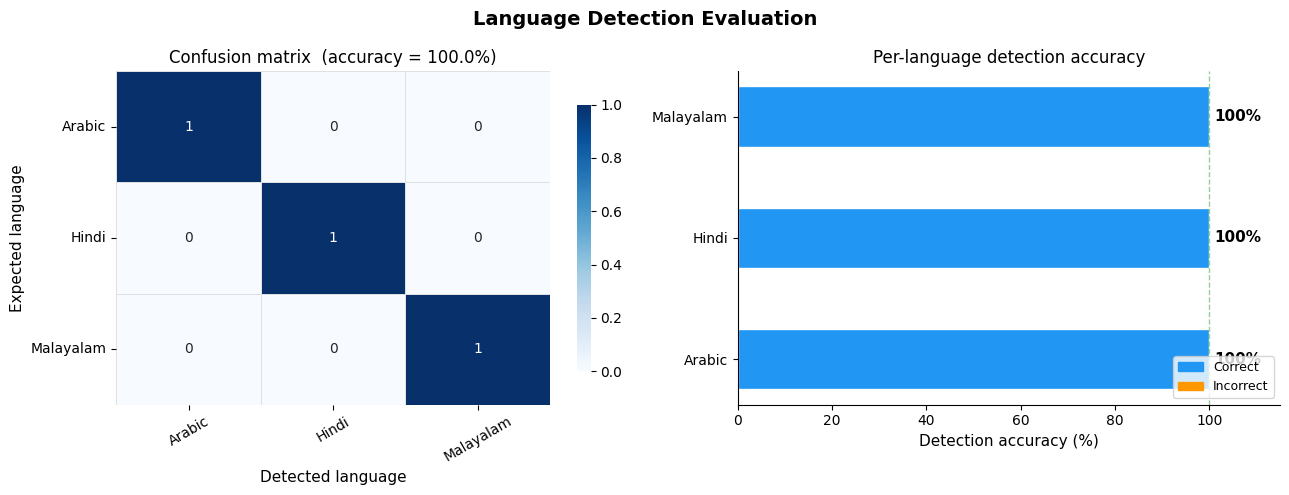

Overall language detection accuracy: 100.0%


In [ ]:
# Cell 13 — Language detection confusion matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

all_codes  = sorted(set(r['lang_code'] for r in results))
code_label = {'ml': 'Malayalam', 'ar': 'Arabic', 'hi': 'Hindi'}
all_labels = [code_label.get(c, c) for c in all_codes]
n = len(all_codes)
cm = np.zeros((n, n), dtype=int)
for r in results:
    i = all_codes.index(r['lang_code'])
    j = all_codes.index(r['detected_lang']) if r['detected_lang'] in all_codes else i
    cm[i][j] += 1
overall_acc = cm.diagonal().sum() / cm.sum()
class_acc   = cm.diagonal() / cm.sum(axis=1).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Language Detection Evaluation', fontsize=14, fontweight='bold')

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=all_labels, yticklabels=all_labels,
    linewidths=0.5, linecolor='#e0e0e0',
    cbar_kws={'shrink': 0.8}, ax=axes[0]
)
axes[0].set_xlabel('Detected language', fontsize=11)
axes[0].set_ylabel('Expected language', fontsize=11)
axes[0].set_title(f'Confusion matrix  (accuracy = {overall_acc:.1%})', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

colors = ['#2196F3' if a == 1.0 else '#FF9800' for a in class_acc]
bars = axes[1].barh(all_labels, class_acc * 100, color=colors, height=0.5, edgecolor='white')
for bar, acc_val in zip(bars, class_acc):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{acc_val:.0%}', va='center', fontsize=11, fontweight='bold')
axes[1].set_xlim(0, 115)
axes[1].set_xlabel('Detection accuracy (%)', fontsize=11)
axes[1].set_title('Per-language detection accuracy', fontsize=12)
axes[1].axvline(100, color='#4CAF50', linestyle='--', linewidth=1, alpha=0.6)
axes[1].legend(
    handles=[mpatches.Patch(color='#2196F3', label='Correct'), mpatches.Patch(color='#FF9800', label='Incorrect')],
    loc='lower right', fontsize=9
)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('language_detection_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Overall language detection accuracy: {overall_acc:.1%}')


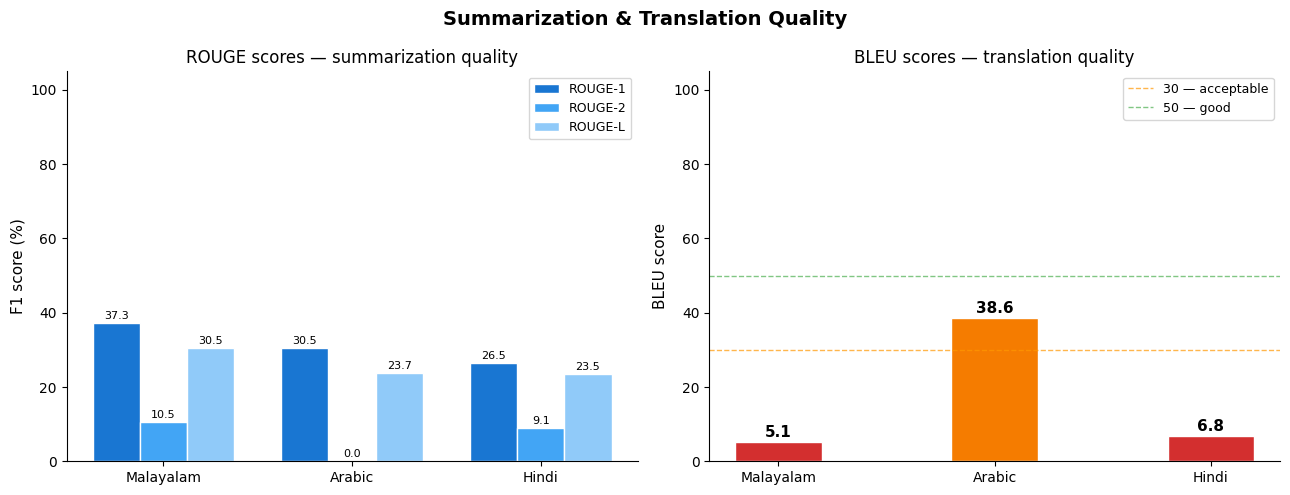

In [ ]:
# Cell 14 — ROUGE & BLEU score visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Summarization & Translation Quality', fontsize=14, fontweight='bold')

labels      = [r['label'] for r in results]
r1_scores   = [r['rouge1'] * 100 for r in results]
r2_scores   = [r['rouge2'] * 100 for r in results]
rl_scores   = [r['rougeL'] * 100 for r in results]
bleu_scores = [r['bleu'] for r in results]

x = np.arange(len(labels))
w = 0.25

b1 = axes[0].bar(x - w, r1_scores, w, label='ROUGE-1', color='#1976D2', edgecolor='white')
b2 = axes[0].bar(x,     r2_scores, w, label='ROUGE-2', color='#42A5F5', edgecolor='white')
b3 = axes[0].bar(x + w, rl_scores, w, label='ROUGE-L', color='#90CAF9', edgecolor='white')
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                     f'{h:.1f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('F1 score (%)', fontsize=11)
axes[0].set_title('ROUGE scores — summarization quality', fontsize=12)
axes[0].set_ylim(0, 105)
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

bar_colors = ['#388E3C' if s >= 50 else '#F57C00' if s >= 30 else '#D32F2F' for s in bleu_scores]
bars = axes[1].bar(labels, bleu_scores, color=bar_colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, bleu_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].axhline(30, color='#FF9800', linestyle='--', linewidth=1, alpha=0.7, label='30 — acceptable')
axes[1].axhline(50, color='#4CAF50', linestyle='--', linewidth=1, alpha=0.7, label='50 — good')
axes[1].set_ylabel('BLEU score', fontsize=11)
axes[1].set_title('BLEU scores — translation quality', fontsize=12)
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('rouge_bleu_scores.png', dpi=150, bbox_inches='tight')
plt.show()


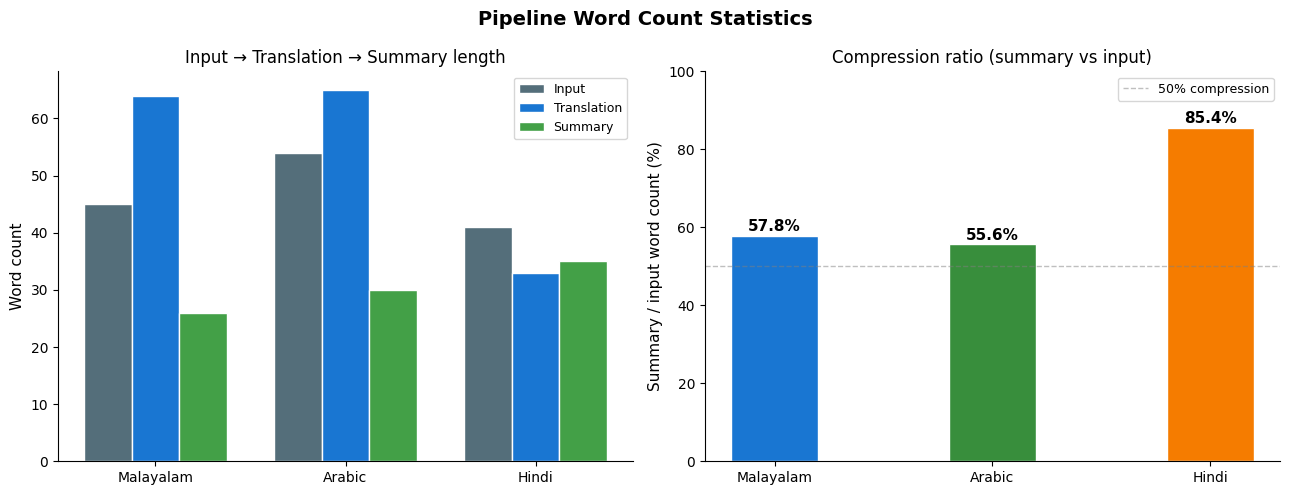

In [ ]:
# Cell 15 — Word count & compression ratio
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Pipeline Word Count Statistics', fontsize=14, fontweight='bold')

labels    = [r['label'] for r in results]
input_wc  = [r['input_words']       for r in results]
transl_wc = [r['translation_words'] for r in results]
summ_wc   = [r['summary_words']     for r in results]
comp_pct  = [r['compression'] * 100 for r in results]

x = np.arange(len(labels))
w = 0.25
axes[0].bar(x - w, input_wc,  w, label='Input',       color='#546E7A', edgecolor='white')
axes[0].bar(x,     transl_wc, w, label='Translation', color='#1976D2', edgecolor='white')
axes[0].bar(x + w, summ_wc,   w, label='Summary',     color='#43A047', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Word count', fontsize=11)
axes[0].set_title('Input → Translation → Summary length', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

bar_colors = ['#1976D2', '#388E3C', '#F57C00']
bars = axes[1].bar(labels, comp_pct, color=bar_colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, comp_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50% compression')
axes[1].set_ylabel('Summary / input word count (%)', fontsize=11)
axes[1].set_title('Compression ratio (summary vs input)', fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('pipeline_stats.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Cell 16 — Final metrics summary table
import pandas as pd

df = pd.DataFrame([{
    'Language':       r['label'],
    'Domain':         r['domain'],
    'Lang detected':  'CORRECT' if r['lang_correct'] else 'WRONG',
    'ROUGE-1':        round(r['rouge1'], 3),
    'ROUGE-2':        round(r['rouge2'], 3),
    'ROUGE-L':        round(r['rougeL'], 3),
    'BLEU':           round(r['bleu'], 1),
    'Input words':    r['input_words'],
    'Summary words':  r['summary_words'],
    'Compression':    f"{r['compression']:.0%}",
} for r in results])

print('\n' + '='*80)
print('  COMPLETE EVALUATION RESULTS')
print('='*80)
print(df.to_string(index=False))
print('='*80)
print(f"\n  Language detection accuracy : {sum(r['lang_correct'] for r in results)/len(results):.1%}")
print(f"  Avg ROUGE-1 (F1)            : {sum(r['rouge1'] for r in results)/len(results):.3f}")
print(f"  Avg ROUGE-2 (F1)            : {sum(r['rouge2'] for r in results)/len(results):.3f}")
print(f"  Avg ROUGE-L (F1)            : {sum(r['rougeL'] for r in results)/len(results):.3f}")
print(f"  Avg BLEU (translation)      : {sum(r['bleu'] for r in results)/len(results):.1f}")
print('='*80)



  COMPLETE EVALUATION RESULTS
 Language  Domain Lang detected  ROUGE-1  ROUGE-2  ROUGE-L  BLEU  Input words  Summary words Compression
Malayalam  Sports       CORRECT    0.373    0.105    0.305   5.1           45             26         58%
   Arabic Science       CORRECT    0.305    0.000    0.237  38.6           54             30         56%
    Hindi  Policy       CORRECT    0.265    0.091    0.235   6.8           41             35         85%

  Language detection accuracy : 100.0%
  Avg ROUGE-1 (F1)            : 0.314
  Avg ROUGE-2 (F1)            : 0.065
  Avg ROUGE-L (F1)            : 0.259
  Avg BLEU (translation)      : 16.8
